# Лабораторная работа №4

## Правильный многоугольник Рело. Векторизация вычислений в `numpy`

Кравченко Сергей  
**Курс:** 1  
**Группа:** 5  


# Задание 4.1. Построение треугольника Рело

Построить представление границы правильного треугольника Рело в виде матрицы, каждая строка которой содержит координаты точек, последовательно описывающих границу.


In [27]:
import numpy as np
import matplotlib.pyplot as plt

In [28]:
n = 3                         # количество вершин треугольника Рело
center = np.array([0, 0])     # координаты центра треугольника Рело
r = 10.                       # ширина треугольника Рело
N = 100                       # количество точек для описания одной стороны

In [29]:
l = r
R = l / (2 * np.sin(np.pi / n))
R

np.float64(5.773502691896258)

Вершины строятся по параметрическому описанию окружности:

\[
x(t)=x_0+R\cos t,\qquad y(t)=y_0+R\sin t,
\]

где

\[
t\in \{0,2\pi/3,4\pi/3\}.
\]

In [30]:
t = np.arange(0, 2 * np.pi, 2 * np.pi / n)
vertices = center + R * np.transpose([np.cos(t), np.sin(t)])
vertices

array([[ 5.77350269,  0.        ],
       [-2.88675135,  5.        ],
       [-2.88675135, -5.        ]])

### Пояснение к выражению

```python
vertices = center + R*np.transpose([np.cos(t), np.sin(t)])
```

1. `t` — массив углов для вершин.
2. `np.cos(t)` сразу вычисляет все \(x\)-координаты на единичной окружности.
3. `np.sin(t)` сразу вычисляет все \(y\)-координаты.
4. `np.transpose([np.cos(t), np.sin(t)])` создает матрицу из двух столбцов: \(x\) и \(y\).
5. Умножение на `R` масштабирует окружность.
6. Прибавление `center` переносит все вершины в нужный центр.

Это векторизация вычислений в `numpy`, потому что явный цикл не используется.

In [31]:
vertices[0, 0], vertices[0, :], vertices[:, 1]

(np.float64(5.773502691896258),
 array([5.77350269, 0.        ]),
 array([ 0.,  5., -5.]))

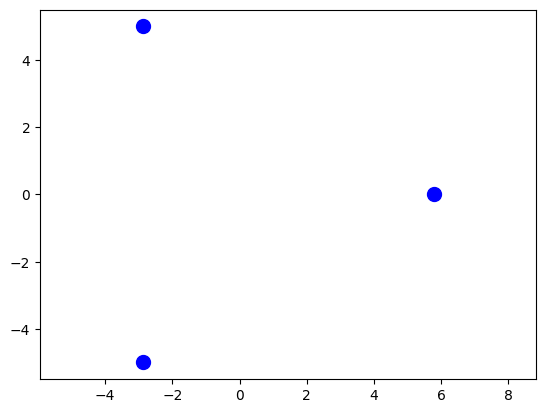

In [32]:
plt.plot(vertices[:, 0], vertices[:, 1], 'b.', markersize=20)
plt.axis('equal');

In [33]:
alpha = 2 * np.pi / n
beta = alpha / 2

In [34]:
angle = np.linspace(-beta / 2, beta / 2, N)

In [35]:
side0 = vertices[0] + r * np.transpose([
    np.cos(np.pi + angle),
    np.sin(np.pi + angle)
])

### Формулы параметрического описания точек стороны треугольника Рело

Если центр дуги \(V_0=(x_0,y_0)\), то дуга радиуса \(r\) задается формулами:

\[
x(\varphi)=x_0+r\cos\varphi,
\]

\[
y(\varphi)=y_0+r\sin\varphi.
\]

Для первой стороны:

\[
\varphi=\pi+\theta,\qquad
\theta\in\left[-\frac{\beta}{2},\frac{\beta}{2}\right].
\]

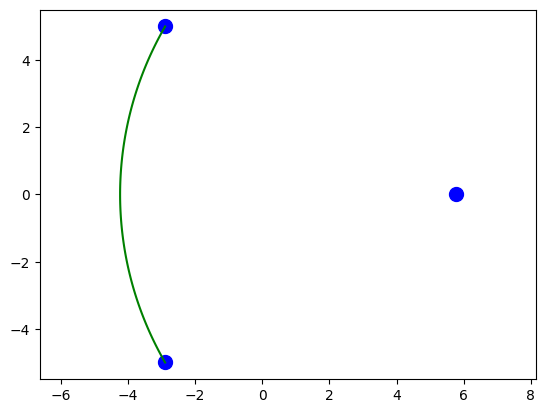

In [36]:
plt.plot(vertices[:, 0], vertices[:, 1], 'b.', markersize=20)
plt.plot(side0[:, 0], side0[:, 1], 'g-', markersize=20)
plt.axis('equal');

In [37]:
side1 = vertices[1] + r * np.transpose([
    np.cos(np.pi + angle + alpha),
    np.sin(np.pi + angle + alpha)
])

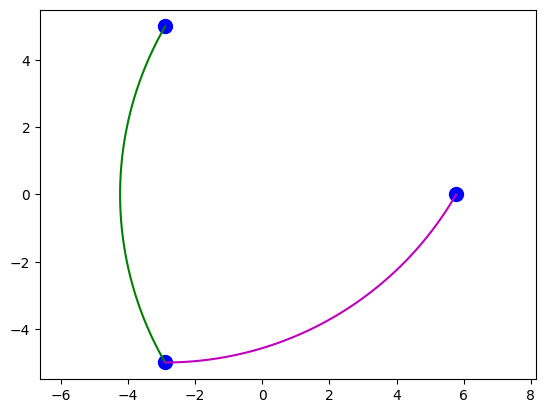

In [38]:
plt.plot(vertices[:, 0], vertices[:, 1], 'b.', markersize=20)
plt.plot(side0[:, 0], side0[:, 1], 'g-', markersize=20)
plt.plot(side1[:, 0], side1[:, 1], 'm-', markersize=20)
plt.axis('equal');

In [39]:
list_sides = [
    vertices[i] + r * np.transpose([
        np.cos(angle + np.pi + i * alpha),
        np.sin(angle + np.pi + i * alpha)
    ])
    for i in range(n)
]

In [40]:
sides = np.concatenate(list_sides)
sides.shape

(300, 2)

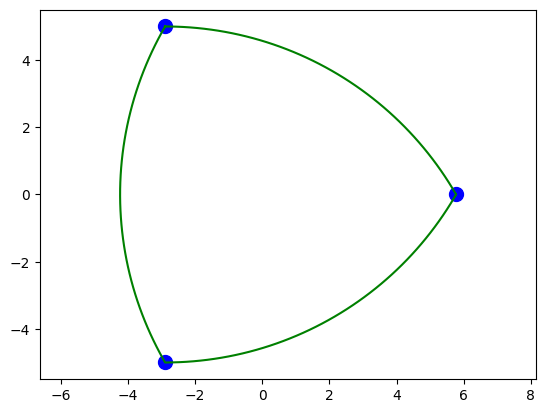

In [41]:
plt.plot(vertices[:, 0], vertices[:, 1], 'b.', markersize=20)
plt.plot(sides[:, 0], sides[:, 1], 'g-', markersize=20)
plt.axis('equal');

# Задание 4.2. Построение правильного многоугольника Рело

Создать матричное описание границы правильного многоугольника Рело для произвольных `n`, `center`, `r`, `N`. Количество вершин должно быть нечетным.

## Аналитическая зависимость \(l\) от \(n\) и \(r\)

Для правильного \(n\)-угольника:

\[
l=2R\sin\frac{\pi}{n}.
\]

В многоугольнике Рело расстояние от вершины-центра дуги до конца дуги равно ширине \(r\). Для нечетного \(n\) это хорда описанной окружности с центральным углом:

\[
\frac{(n-1)\pi}{n}.
\]

Тогда:

\[
r=2R\sin\frac{(n-1)\pi}{2n}
=2R\cos\frac{\pi}{2n}.
\]

Отсюда:

\[
R=\frac{r}{2\cos(\pi/(2n))}.
\]

Подставим в формулу стороны:

\[
l=2\cdot \frac{r}{2\cos(\pi/(2n))}\cdot \sin\frac{\pi}{n}.
\]

Так как

\[
\sin\frac{\pi}{n}=2\sin\frac{\pi}{2n}\cos\frac{\pi}{2n},
\]

получаем:

\[
\boxed{l=2r\sin\frac{\pi}{2n}}.
\]

Для \(n=3\):

\[
l=2r\sin\frac{\pi}{6}=r.
\]

In [42]:
n = 5
center = np.array([0, 0])
r = 10.
N = 100

l = 2 * r * np.sin(np.pi / (2 * n))
R = l / (2 * np.sin(np.pi / n))

t = np.arange(0, 2 * np.pi, 2 * np.pi / n)
vertices = center + R * np.transpose([np.cos(t), np.sin(t)])

alpha = 2 * np.pi / n
beta = np.pi / n
angle = np.linspace(-beta, beta, N)

list_sides = [
    vertices[i] + r * np.transpose([
        np.cos(np.pi + angle + i * alpha),
        np.sin(np.pi + angle + i * alpha)
    ])
    for i in range(n)
]

sides = np.concatenate(list_sides)

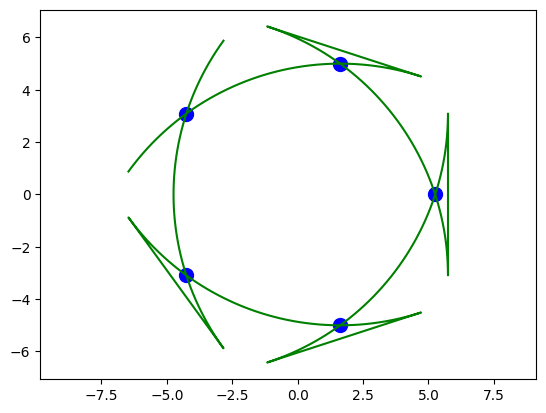

In [43]:
plt.plot(vertices[:, 0], vertices[:, 1], 'b.', markersize=20)
plt.plot(sides[:, 0], sides[:, 1], 'g-')
plt.axis('equal');

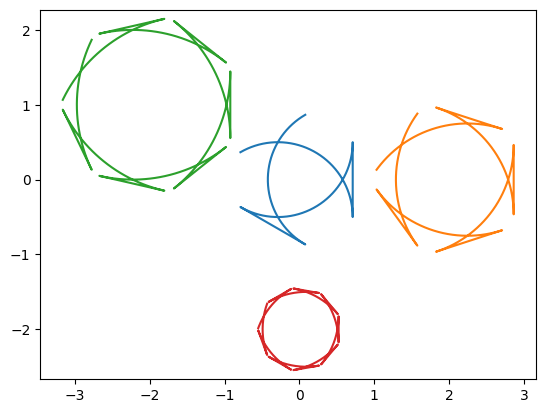

In [44]:
test_values = [
    (3, np.array([0, 0]), 1., 40),
    (5, np.array([2, 0]), 1.5, 60),
    (7, np.array([-2, 1]), 2., 80),
    (9, np.array([0, -2]), 1., 100)
]

plt.figure()

for n_test, center_test, r_test, N_test in test_values:
    l_test = 2 * r_test * np.sin(np.pi / (2 * n_test))
    R_test = l_test / (2 * np.sin(np.pi / n_test))

    t_test = np.arange(0, 2 * np.pi, 2 * np.pi / n_test)
    vertices_test = center_test + R_test * np.transpose([np.cos(t_test), np.sin(t_test)])

    alpha_test = 2 * np.pi / n_test
    beta_test = np.pi / n_test
    angle_test = np.linspace(-beta_test, beta_test, N_test)

    list_sides_test = [
        vertices_test[i] + r_test * np.transpose([
            np.cos(np.pi + angle_test + i * alpha_test),
            np.sin(np.pi + angle_test + i * alpha_test)
        ])
        for i in range(n_test)
    ]

    sides_test = np.concatenate(list_sides_test)
    plt.plot(sides_test[:, 0], sides_test[:, 1])

plt.axis('equal');

# Задание 4.3. Результирующая пользовательская функция

## 4.3a

Написать функцию `regular_polygon_Relo(n, center, r, N)`, которая возвращает матрицу координат точек границы правильного многоугольника Рело.


In [45]:
def regular_polygon_Relo(n: int = 3,
                         center: np.ndarray = np.array([0, 0]),
                         r: float = 1,
                         N: int = 100) -> np.ndarray:

    assert isinstance(n, int), 'n should be integer'
    assert n > 2, 'n should be greater than 2'
    assert n % 2 == 1, 'n should be odd'
    assert isinstance(center, np.ndarray), 'center should be numpy.ndarray'
    assert center.shape == (2,), 'center should have shape (2,)'
    assert r > 0, 'width r should be positive'
    assert isinstance(N, int), 'N should be integer'
    assert N > 0, 'N should be positive'

    l = 2 * r * np.sin(np.pi / (2 * n))
    R = l / (2 * np.sin(np.pi / n))

    t = np.arange(0, 2 * np.pi, 2 * np.pi / n)
    vertices = center + R * np.transpose([np.cos(t), np.sin(t)])

    alpha = 2 * np.pi / n
    beta = np.pi / n
    angle = np.linspace(-beta, beta, N)

    list_sides = [
        vertices[i] + r * np.transpose([
            np.cos(np.pi + i * alpha + angle),
            np.sin(np.pi + i * alpha + angle)
        ])
        for i in range(n)
    ]

    sides = np.concatenate(list_sides)
    return sides

## 4.3b

Контроль значений аргументов осуществляется с помощью `assert`.

Проверяются:

- `n` является целым числом;
- `n > 2`;
- `n` нечетное;
- `center` является `np.ndarray`;
- `center` имеет форму `(2,)`;
- `r > 0`;
- `N` является целым;
- `N > 0`.

In [46]:
regular_polygon_Relo(3, np.array([0, 0]), 1, 100).shape

(300, 2)

In [47]:
try:
    regular_polygon_Relo(4, np.array([0, 0]), 1, 100)
except AssertionError as error:
    print(type(error).__name__ + ':', error)

AssertionError: n should be odd


In [48]:
try:
    regular_polygon_Relo(5, np.array([0, 0]), -1, 100)
except AssertionError as error:
    print(type(error).__name__ + ':', error)

AssertionError: width r should be positive


In [49]:
try:
    regular_polygon_Relo(5, np.array([0, 0]), 1, 0)
except AssertionError as error:
    print(type(error).__name__ + ':', error)

AssertionError: N should be positive


In [50]:
regular_polygon_Relo.__annotations__

{'n': int,
 'center': numpy.ndarray,
 'r': float,
 'N': int,
 'return': numpy.ndarray}

In [51]:
print(regular_polygon_Relo.__doc__)

None


## 4.3d

Создать модуль `relo.py`, в котором содержится функция `regular_polygon_Relo`.

Файл `relo.py` приложен вместе с ноутбуком. В ячейке ниже показан его текст.

In [52]:
from pathlib import Path
print(Path('relo.py').read_text(encoding='utf-8'))

# Задание 4.4. Тестирование пользовательской функции

## 4.4a

Протестировать функцию `regular_polygon_Relo` из модуля `relo` для разных значений аргументов в предположении, что корректность вводимых данных не гарантируется.

Перед тестированием по инструкции нужно очистить ядро Python, затем заново импортировать модуль.

In [53]:
# После очистки ядра Python эту ячейку нужно выполнить первой.
import numpy as np
import matplotlib.pyplot as plt
from relo import regular_polygon_Relo

ModuleNotFoundError: No module named 'relo'

In [ ]:
correct_tests = [
    (3, np.array([0, 0]), 1, 100),
    (5, np.array([1, 0]), 2, 80),
    (7, np.array([-1, 1]), 1.5, 60),
    (9, np.array([0, -1]), 1, 50)
]

for test in correct_tests:
    result = regular_polygon_Relo(*test)
    print('arguments =', test, 'result shape =', result.shape)

In [ ]:
incorrect_tests = [
    (4, np.array([0, 0]), 1, 100),
    (1, np.array([0, 0]), 1, 100),
    (5, [0, 0], 1, 100),
    (5, np.array([0, 0, 0]), 1, 100),
    (5, np.array([0, 0]), 0, 100),
    (5, np.array([0, 0]), 1, -10)
]

for test in incorrect_tests:
    try:
        regular_polygon_Relo(*test)
    except AssertionError as error:
        print('arguments =', test, '=>', type(error).__name__ + ':', error)

## 4.4b

Построить в одной системе координат правильные многоугольники Рело для различных значений `n`, `center`, `r`, `N`.

Функцию нужно вызвать разными способами:

1. все аргументы позиционные;
2. все аргументы ключевые;
3. позиционные и ключевые;
4. все аргументы по умолчанию.

In [ ]:
plt.figure()

# 1. Все аргументы позиционные
relo1 = regular_polygon_Relo(3, np.array([0, 0]), 1, 100)
plt.plot(relo1[:, 0], relo1[:, 1], label='позиционные аргументы')

# 2. Все аргументы ключевые
relo2 = regular_polygon_Relo(n=5, center=np.array([1, 0]), r=1, N=80)
plt.plot(relo2[:, 0], relo2[:, 1], label='ключевые аргументы')

# 3. Аргументы позиционные и ключевые
relo3 = regular_polygon_Relo(7, np.array([-1, 1]), r=1, N=60)
plt.plot(relo3[:, 0], relo3[:, 1], label='позиционные + ключевые')

# 4. Все аргументы по умолчанию
relo4 = regular_polygon_Relo()
plt.plot(relo4[:, 0], relo4[:, 1], label='стандартные значения')

plt.axis('equal')
plt.legend();